# Bayesian inverse problems with ODEs and PDEs

Many quantities cannot be measured directly; they are visible only through a dynamical system they drive.
A reaction rate is seen through a decay curve, a transmission rate through an epidemic's case counts, a
contaminant source through downstream concentrations, a material's diffusivity through a temperature
field. The forward problem predicts the system's output given those drivers; the inverse problem, which is
what we usually face, recovers the drivers from noisy, partial, indirect observations of the output, with
honest uncertainty.

This notebook treats that as Bayesian inference. The forward model is the solution of an ordinary or
partial differential equation; the unknown drivers (coefficients, source terms, initial conditions) are
latent variables declared with `free`; and a `Differential` observation, fit through `joint([...]).fit()`,
returns a joint posterior. The differential equation is solved by a differentiable integrator, so the same
gradient-based machinery that fits a regression fits the physics. The single callback that supplies the
equation is handed a `p` namespace (the drivers by name) and an `ops` namespace (backend-agnostic math),
so model code never touches a tensor library. The pattern is domain-agnostic: pharmacokinetics,
epidemiology, chemical kinetics, heat-equation source recovery, groundwater transport, tomography.

## 1. An ODE inverse problem: a rate from a curve

Exponential decay, $\dot y = -k y$ with $y(0)=1$, observed at noisy times. The decay constant $k$ is the
latent driver: a positive `free` parameter the forward model reads as `p.k`. The posterior over $k$ is
read off the fit.

posterior decay rate k = 0.774 +/- 0.015   (true 0.80)


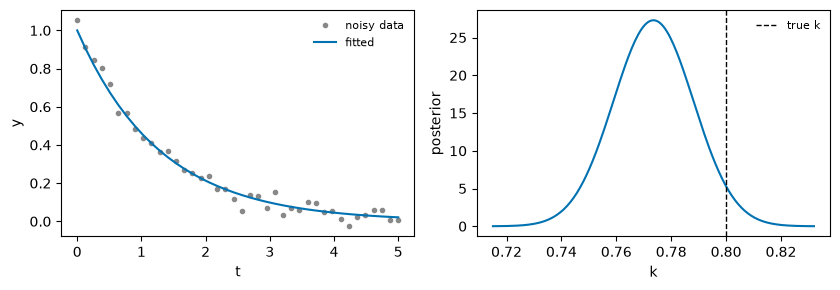

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import torch
from mixle.ppl import GP, joint, free, GaussianField, RandomWalk
from mixle_pde import Differential

def rk4(rhs, y0, t):                       # a transparent reference integrator (matches the framework)
    ys, y = [y0], y0
    for i in range(len(t) - 1):
        h = t[i+1] - t[i]
        k1 = rhs(y, t[i]); k2 = rhs(y + 0.5*h*k1, t[i] + 0.5*h)
        k3 = rhs(y + 0.5*h*k2, t[i] + 0.5*h); k4 = rhs(y + h*k3, t[i] + h)
        y = y + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4); ys.append(y)
    return np.array(ys)

rng = np.random.RandomState(0)
t = np.linspace(0, 5, 40)
k_true, sig = 0.8, 0.03
y = rk4(lambda u, tt: -k_true * u, 1.0, t) + sig * rng.randn(len(t))

k = free(1, name="k", support="positive")
obs = Differential(y, drivers=[k], y0=1.0, t_grid=t, scale=sig, rhs=lambda u, t, p, ops: -p.k * u)
post = joint([obs]).fit(how="laplace", init={"k": 1.0})   # positive nodes start at 1, not 0
k_mean, k_sd = post.posterior("k")
print('posterior decay rate k = %.3f +/- %.3f   (true %.2f)' % (k_mean, k_sd, k_true))

fig, ax = plt.subplots(1, 2, figsize=(8.5, 3.0))
ax[0].plot(t, y, 'o', ms=3, color='#888', label='noisy data')
ax[0].plot(t, rk4(lambda u, tt: -k_mean * u, 1.0, t), color='#0072B2', label='fitted')
ax[0].set_xlabel('t'); ax[0].set_ylabel('y'); ax[0].legend(fontsize=8, frameon=False)
g = np.linspace(k_mean - 4*k_sd, k_mean + 4*k_sd, 200)
ax[1].plot(g, np.exp(-0.5*((g-k_mean)/k_sd)**2)/(k_sd*np.sqrt(2*np.pi)), color='#0072B2')
ax[1].axvline(k_true, color='k', ls='--', lw=1, label='true k'); ax[1].set_xlabel('k'); ax[1].set_ylabel('posterior')
ax[1].legend(fontsize=8, frameon=False); plt.tight_layout(); plt.show()

## 2. A nonlinear ODE, several parameters at once

Nothing changes when the dynamics are nonlinear and there are several unknowns. Logistic growth $\dot y =
r\,y(1 - y/K)$ has a growth rate $r$ and a carrying capacity $K$, both recovered jointly with posteriors
from one noisy trajectory. The same call would fit a Lotka-Volterra system, an SIR epidemic, or a
pharmacokinetic model -- only the right-hand side differs.

growth rate       r = 0.896 +/- 0.005   (true 0.90)
carrying capacity K = 5.010 +/- 0.012   (true 5.00)


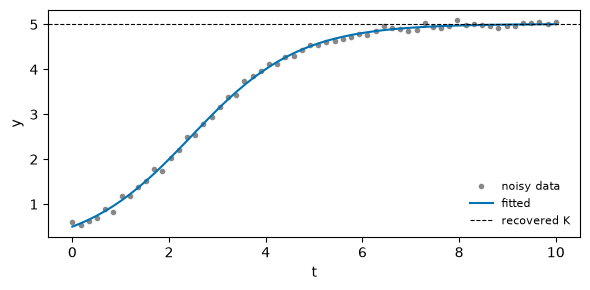

In [2]:
rng = np.random.RandomState(1)
t = np.linspace(0, 10, 60)
r_true, K_true, sig = 0.9, 5.0, 0.06
y = rk4(lambda u, tt: r_true * u * (1 - u / K_true), 0.5, t) + sig * rng.randn(len(t))

r = free(1, name="r", support="positive")
K = free(1, name="K", support="positive")
obs = Differential(y, drivers=[r, K], y0=0.5, t_grid=t, scale=sig,
                   rhs=lambda u, t, p, ops: p.r * u * (1 - u / p.K))
post = joint([obs]).fit(how="laplace", init={"r": 1.0, "K": 1.0})   # positive nodes start at 1, not 0
rm, rs = post.posterior("r"); Km, Ks = post.posterior("K")
print('growth rate       r = %.3f +/- %.3f   (true %.2f)' % (rm, rs, r_true))
print('carrying capacity K = %.3f +/- %.3f   (true %.2f)' % (Km, Ks, K_true))
fig, ax = plt.subplots(figsize=(6.0, 3.0))
ax.plot(t, y, 'o', ms=3, color='#888', label='noisy data')
ax.plot(t, rk4(lambda u, tt: rm * u * (1 - u / Km), 0.5, t), color='#0072B2', label='fitted')
ax.axhline(Km, color='k', ls='--', lw=0.8, label='recovered K'); ax.set_xlabel('t'); ax.set_ylabel('y')
ax.legend(fontsize=8, frameon=False); plt.tight_layout(); plt.show()

## 3. A PDE inverse problem: recovering a source field

Now the unknown is a whole field. A substance diffuses to a steady state under a spatial source, $-D\,u''
= q(x)$ with $u=0$ at the ends, and we observe the concentration at a handful of interior sensors; the
task is to recover $q(x)$ everywhere. This is ill-posed -- many sources fit a few measurements -- so we
regularize with a smoothness prior on the field, the role a prior plays in any inverse problem. The shared
field of a `GP` is the source (`p.field`); the `forward` callback solves the linear system and `observe`
reads the sensors.

source recovery: corr(recovered, true) = 0.959


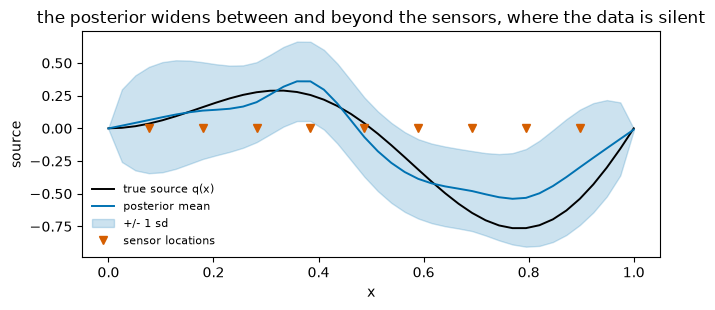

In [3]:
n = 40; x = np.linspace(0, 1, n); hx = x[1] - x[0]
L = np.zeros((n, n))
for i in range(1, n-1):
    L[i, i-1] = -1/hx**2; L[i, i] = 2/hx**2; L[i, i+1] = -1/hx**2
L[0, 0] = L[-1, -1] = 1.0
q_true = np.sin(2*np.pi*x) * x; q_true[0] = q_true[-1] = 0.0
sens = np.arange(3, n-3, 4); sig = 0.003
u_obs = np.linalg.solve(L, q_true)[sens] + sig * np.random.RandomState(2).randn(len(sens))

q = GP("q", index=np.arange(n), kernel=RandomWalk(scale=0.3, ridge=5.0))
Lt = torch.as_tensor(L); sens_t = torch.as_tensor(sens)
obs = Differential(u_obs, over=q, scale=sig,
                   forward=lambda p, ops: ops.solve(Lt, p.field),
                   observe=lambda u, p, ops: u[sens_t])
post = joint([obs]).fit(how="laplace")
qm, qs = post.posterior("q")
print('source recovery: corr(recovered, true) = %.3f' % np.corrcoef(qm, q_true)[0, 1])

fig, ax = plt.subplots(figsize=(6.8, 3.2))
ax.plot(x, q_true, color='k', lw=1.4, label='true source q(x)')
ax.plot(x, qm, color='#0072B2', lw=1.4, label='posterior mean')
ax.fill_between(x, qm - qs, qm + qs, color='#0072B2', alpha=0.2, label='+/- 1 sd')
ax.plot(x[sens], np.zeros(len(sens)), 'v', color='#D55E00', ms=6, label='sensor locations')
ax.set_xlabel('x'); ax.set_ylabel('source'); ax.legend(fontsize=8, frameon=False)
ax.set_title('the posterior widens between and beyond the sensors, where the data is silent')
plt.tight_layout(); plt.show()

The recovered uncertainty is exact, not heuristic: when the forward map is linear and the noise Gaussian
the posterior over the source is Gaussian, and the Laplace covariance the fit returns equals it. The
prediction at the sensors is $u = (H L^{-1}) q$, linear in $q$, so the posterior precision is the prior
precision plus $G^\top G / \sigma^2$ with $G = H L^{-1}$.

In [4]:
G = np.linalg.inv(L)[sens, :]
sd_closed_form = np.sqrt(np.diag(np.linalg.inv(q.field.precision + G.T @ G / sig**2)))
print('max |Laplace sd - exact Gaussian sd| = %.2e' % np.max(np.abs(qs - sd_closed_form)))

max |Laplace sd - exact Gaussian sd| = 8.22e-15


## 4. Recovering a coefficient instead of a field

The same steady equation can hide its coefficient: given a known source, recover the diffusivity $D$ from
the observed field. Here $D$ enters the operator nonlinearly through the solve, and it is a single positive
`free` parameter with its own posterior. The `forward` callback assembles the operator from `p.D` using the
`ops` namespace.

In [5]:
D_true = 2.3
def L_of(D):
    M = np.zeros((n, n))
    for i in range(1, n-1): M[i, i-1] = -D/hx**2; M[i, i] = 2*D/hx**2; M[i, i+1] = -D/hx**2
    M[0, 0] = M[-1, -1] = 1.0; return M
u_obs = np.linalg.solve(L_of(D_true), q_true)[sens] + sig * np.random.RandomState(3).randn(len(sens))
qt = torch.as_tensor(q_true)

def forward(p, ops):
    A = ops.zeros(n, n).clone(); idx = ops.arange(n-2) + 1
    A[idx, idx-1] = -p.D/hx**2; A[idx, idx] = 2*p.D/hx**2; A[idx, idx+1] = -p.D/hx**2
    A[0, 0] = 1.0; A[-1, -1] = 1.0
    return ops.solve(A, qt)

D = free(1, name="D", support="positive")
obs = Differential(u_obs, drivers=[D], scale=sig, forward=forward, observe=lambda u, p, ops: u[sens_t])
Dm, Ds = joint([obs]).fit(how="laplace", init={"D": 1.0}).posterior("D")
print('posterior diffusivity D = %.3f +/- %.3f   (true %.2f)' % (Dm, Ds, D_true))

posterior diffusivity D = 2.041 +/- 0.253   (true 2.30)

## Scaling to large fields

The dense `ops.solve` above is fine for these teaching sizes. For a 2-D or 3-D field with thousands to
millions of unknowns, assemble the operator with `ops.divergence_form` / `ops.helmholtz_operator` and solve
with `ops.sparse_solve`, which uses a sparse factorization and the adjoint method -- the gradient costs one
extra solve regardless of how many field values are unknown. A coefficient field is then recovered with
`how="map"` at a scale a dense solve could not hold; calibrated posteriors at that scale are the next piece
of the stack.

## In short

- An unobservable driver of a dynamical system -- a rate, a source, an initial condition, a material
  coefficient -- is recovered as a Bayesian posterior from noisy partial observations by treating the ODE
  or PDE solution as the forward model.
- `Differential` plugs a differentiable solve into `joint([...]).fit()`; the driver is a `free` handle or
  the shared field of a `GP`, and a single callback supplies the physics through backend-agnostic `ops`.
- Inverse problems are typically ill-posed; a prior on the latent makes them well-posed, and the posterior
  is correspondingly wide where the data is silent.
- When the forward map is linear and the noise Gaussian, the Laplace posterior is exact.

## References

- Stuart, A. M. (2010). Inverse problems: a Bayesian perspective. Acta Numerica, 19, 451-559.
- Tarantola, A. (2005). Inverse Problem Theory and Methods for Model Parameter Estimation. SIAM.
- Kaipio, J. & Somersalo, E. (2005). Statistical and Computational Inverse Problems. Springer.
- Plessix, R.-E. (2006). A review of the adjoint-state method for computing the gradient of a functional with geophysical applications. Geophysical Journal International, 167(2), 495-503.

## Exercises and extensions

1. Identifiability. Observe only the early part of the logistic curve (before the plateau) and show that
   the carrying-capacity posterior widens dramatically -- the data no longer constrains $K$.
2. An SIR epidemic. Implement $\dot S = -\beta SI,\ \dot I = \beta SI - \gamma I,\ \dot R = \gamma I$ as a
   vector right-hand side, observe noisy $I(t)$, and recover the posterior over $(\beta, \gamma)$ and
   $R_0 = \beta/\gamma$.
3. Sensor placement. For source recovery, compare the posterior width under sensors clustered in the centre
   versus spread evenly, and relate it to where $G = H L^{-1}$ is informative.
4. Scale up. Move source recovery to a 2-D grid using `ops.divergence_form` + `ops.sparse_solve` with
   `how="map"`, and compare runtime and recovery to the dense version.
5. Initial-condition recovery. Make $y_0$ a latent (pass `y0` as a callable reading a driver) and recover it
   from observations taken only at late times.